In [ ]:
pip install av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 54.6 MB/s eta 0:00:00


In [ ]:
av.__version__

'14.3.0'

In [ ]:
import av

def calculate_gop_sizes(video_path):
    container = av.open(video_path)
    gop_sizes = []  # List to store GOP sizes
    frame_counter = 0  # Counter for total frames processed
    last_i_frame = None  # To keep track of the last I-frame

    print("Analyzing frames to calculate GOP sizes...")

    for frame in container.decode(video=0):
        if frame.key_frame:  # Detect I-frames
            if last_i_frame is not None:  # If not the first I-frame
                gop_sizes.append(frame_counter - last_i_frame)  # Frames since last I-frame
            last_i_frame = frame_counter  # Update the position of the last I-frame

        frame_counter += 1  # Increment total frame count

    # Add the last GOP size (if there's a remaining GOP)
    if last_i_frame is not None and last_i_frame < frame_counter:
        gop_sizes.append(frame_counter - last_i_frame)

    return gop_sizes

# Provide the path to your video file
video_path = "/content/dataset_feb3.mp4"
gop_sizes = calculate_gop_sizes(video_path)

# Print GOP sizes
print("GOP sizes (in frames):", gop_sizes)
print("Average GOP size:", sum(gop_sizes) / len(gop_sizes))


Analyzing frames to calculate GOP sizes...
GOP sizes (in frames): [150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 84]
Average GOP size: 146.11764705882354


In [ ]:
import av

def encode_video(input_file, output_file, codec='h264', crf=None, gop_size=15, b_frames=0):
    """Decode and encode the video on-the-fly to avoid excessive memory usage."""
    input_container = av.open(input_file)
    output_container = av.open(output_file, mode='w')

    input_stream = next(s for s in input_container.streams if s.type == 'video')
    frame_rate = int(input_stream.average_rate)  # Get frame rate

    output_stream = output_container.add_stream(codec, rate=frame_rate)
    output_stream.width = input_stream.codec_context.width
    output_stream.height = input_stream.codec_context.height
    output_stream.pix_fmt = 'yuv420p'
    output_stream.gop_size = gop_size

    # Set encoding options
    output_stream.options = {}
    if crf is not None:
        output_stream.options['crf'] = str(crf)
    if b_frames > 0:
        output_stream.options['bf'] = str(b_frames)

    for i, frame in enumerate(input_container.decode(video=0)):
        if i % gop_size == 0:
            frame.pict_type = av.video.frame.PictureType.I  # I-frame
        elif b_frames > 0 and i % 2 == 0:
            frame.pict_type = av.video.frame.PictureType.B  # B-frame
        else:
            frame.pict_type = av.video.frame.PictureType.P  # P-frame

        for packet in output_stream.encode(frame):
            output_container.mux(packet)

    # Flush encoder
    for packet in output_stream.encode():
        output_container.mux(packet)

    output_container.close()
    input_container.close()

def main():
    input_file = '/content/AITr1cam6_snow.mp4'  # Replace with actual input file
    crf_values = [18, 23, 28, 35, 40]
    gop_size = 15  # GOP size

    # Configuration (ii): One I-frame per GOP, rest P-frames
    for crf in crf_values:
        output_file = f'output_i_p_frames_crf_{crf}.mp4'
        print(f"Encoding {output_file}...")
        encode_video(input_file, output_file, crf=crf, gop_size=gop_size, b_frames=0)

    # Configuration (iii): One I-frame per GOP, interleaved P and B frames
    for crf in crf_values:
        output_file = f'output_i_p_b_frames_crf_{crf}.mp4'
        print(f"Encoding {output_file}...")
        encode_video(input_file, output_file, crf=crf, gop_size=gop_size, b_frames=1)

if __name__ == '__main__':
    main()


Encoding 250_output_i_p_frames_crf_18.mp4...
Encoding 250_output_i_p_frames_crf_23.mp4...
Encoding 250_output_i_p_frames_crf_28.mp4...
Encoding 250_output_i_p_frames_crf_35.mp4...
Encoding 250_output_i_p_frames_crf_40.mp4...
Encoding 250_output_i_p_b_frames_crf_18.mp4...
Encoding 250_output_i_p_b_frames_crf_23.mp4...
Encoding 250_output_i_p_b_frames_crf_28.mp4...
Encoding 250_output_i_p_b_frames_crf_35.mp4...
Encoding 250_output_i_p_b_frames_crf_40.mp4...


**Graph Plot**

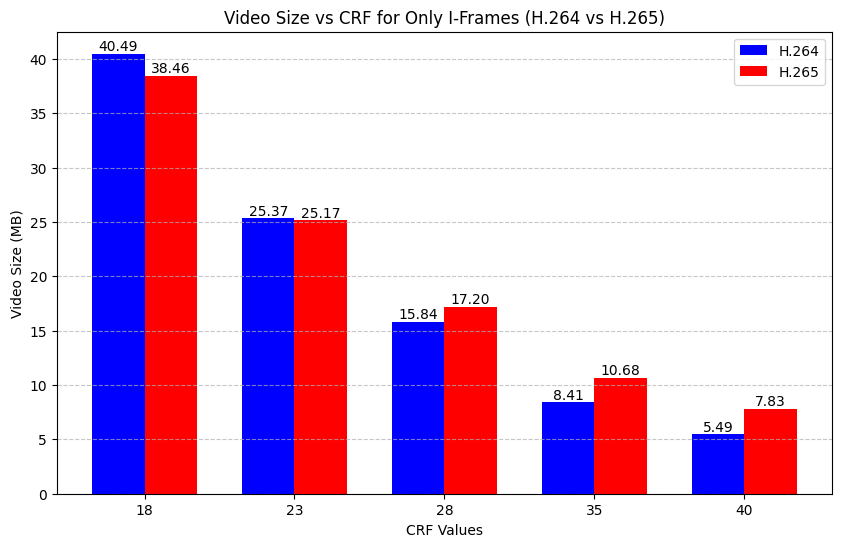

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# CRF values
crf_values = [18, 23, 28, 35, 40]

# Video sizes (in MB) for Only I-frames
h264_sizes = [40.49, 25.37, 15.84, 8.41, 5.49]
h265_sizes = [38.46, 25.17, 17.20, 10.68, 7.83]

# Bar width
bar_width = 0.35
x = np.arange(len(crf_values))

# Create the histogram
plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - bar_width/2, h264_sizes, bar_width, label="H.264", color="blue")
bars2 = plt.bar(x + bar_width/2, h265_sizes, bar_width, label="H.265", color="red")

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
             ha='center', va='bottom', fontsize=10, color='black')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
             ha='center', va='bottom', fontsize=10, color='black')
# Labels and titles
plt.xlabel("CRF Values")
plt.ylabel("Video Size (MB)")
plt.title("Video Size vs CRF for Only I-Frames (H.264 vs H.265)")
plt.xticks(x, crf_values)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()


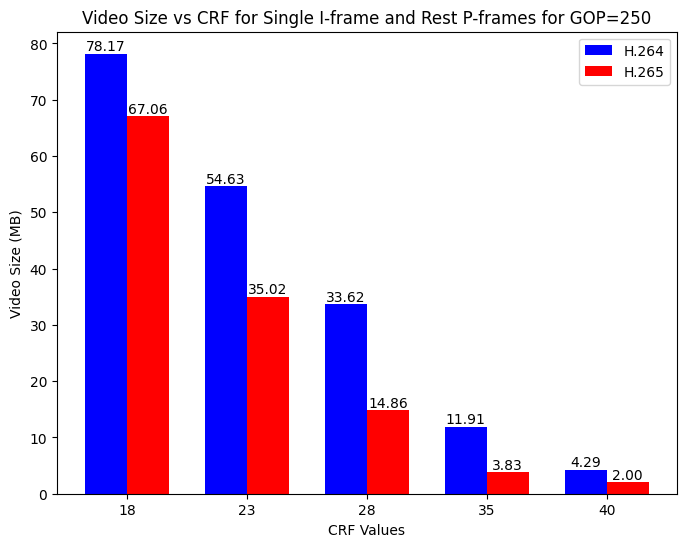

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for Single I-frame and rest P-frames
crf_values = [18, 23, 28, 35, 40]

h264_sizes = [78.17, 54.63, 33.62, 11.91, 4.29]
h265_sizes = [67.06, 35.02, 14.86, 3.83, 2.00]

x = np.arange(len(crf_values))  # Label locations
width = 0.35  # Width of bars

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, h264_sizes, width, label='H.264', color='b')
bars2 = ax.bar(x + width/2, h265_sizes, width, label='H.265', color='r')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
             ha='center', va='bottom', fontsize=10, color='black')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
             ha='center', va='bottom', fontsize=10, color='black')

ax.set_xlabel("CRF Values")
ax.set_ylabel("Video Size (MB)")
ax.set_title("Video Size vs CRF for Single I-frame and Rest P-frames for GOP=250")
ax.set_xticks(x)
ax.set_xticklabels(crf_values)
ax.legend()

plt.show()


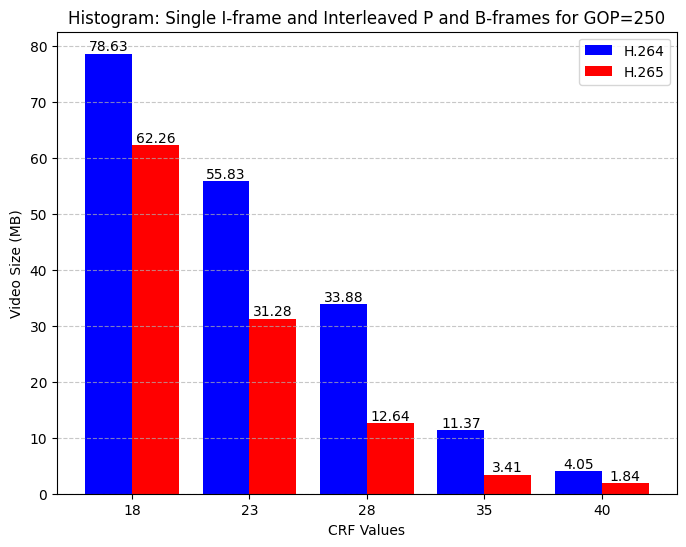

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# CRF values
crf_values = [18, 23, 28, 35, 40]

# Video sizes for H.264 and H.265 (Single I-frame and interleaved P and B-frames)
h264_sizes = [78.63, 55.83, 33.88, 11.37, 4.05]
h265_sizes = [62.26, 31.28, 12.64, 3.41, 1.84]

# Bar width
bar_width = 0.4
x = np.arange(len(crf_values))

# Plotting histogram
plt.figure(figsize=(8, 6))
bars1 = plt.bar(x - bar_width / 2, h264_sizes, width=bar_width, label="H.264", color="b")
bars2 = plt.bar(x + bar_width / 2, h265_sizes, width=bar_width, label="H.265", color="r")

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
             ha='center', va='bottom', fontsize=10, color='black')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
             ha='center', va='bottom', fontsize=10, color='black')

# Labels and title
plt.xlabel("CRF Values")
plt.ylabel("Video Size (MB)")
plt.title("Histogram: Single I-frame and Interleaved P and B-frames for GOP=250")
plt.xticks(x, crf_values)  # Set CRF values as x-ticks
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()


In [ ]:
import av

def encode_video(input_file, output_file, codec='h264', crf=None, gop_size=150, b_frames=0):
    """Decode and encode the video on-the-fly to avoid excessive memory usage."""
    input_container = av.open(input_file)
    output_container = av.open(output_file, mode='w')

    input_stream = next(s for s in input_container.streams if s.type == 'video')
    frame_rate = int(input_stream.average_rate)  # Get frame rate

    output_stream = output_container.add_stream(codec, rate=frame_rate)
    output_stream.width = input_stream.codec_context.width
    output_stream.height = input_stream.codec_context.height
    output_stream.pix_fmt = 'yuv420p'
    output_stream.gop_size = gop_size

    # Set encoding options
    output_stream.options = {}
    if crf is not None:
        output_stream.options['crf'] = str(crf)
    if b_frames > 0:
        output_stream.options['bf'] = str(b_frames)

    for i, frame in enumerate(input_container.decode(video=0)):
        if i % gop_size == 0:
            frame.pict_type = av.video.frame.PictureType.I  # I-frame
        elif b_frames > 0 and i % 2 == 0:
            frame.pict_type = av.video.frame.PictureType.B  # B-frame
        else:
            frame.pict_type = av.video.frame.PictureType.P  # P-frame

        for packet in output_stream.encode(frame):
            output_container.mux(packet)

    # Flush encoder
    for packet in output_stream.encode():
        output_container.mux(packet)

    output_container.close()
    input_container.close()

def main():
    input_file = '/content/MVI_39761.mp4'  # Replace with actual input file
    crf_values = [18, 23, 28, 35, 40]
    gop_size = 150  # Updated GOP size

    # Configuration (i): Only I-frames
    for crf in crf_values:
        output_file = f'output_i_frames_crf_{crf}.mp4'
        print(f"Encoding {output_file}...")
        encode_video(input_file, output_file, crf=crf, gop_size=1, b_frames=0)

    # Configuration (ii): One I-frame per GOP, rest P-frames
    for crf in crf_values:
        output_file = f'output_i_p_frames_crf_{crf}.mp4'
        print(f"Encoding {output_file}...")
        encode_video(input_file, output_file, crf=crf, gop_size=gop_size, b_frames=0)

    # Configuration (iii): One I-frame per GOP, interleaved P and B frames
    for crf in crf_values:
        output_file = f'output_i_p_b_frames_crf_{crf}.mp4'
        print(f"Encoding {output_file}...")
        encode_video(input_file, output_file, crf=crf, gop_size=gop_size, b_frames=1)

if __name__ == '__main__':
    main()


Encoding output_i_frames_crf_18.mp4...
Encoding output_i_frames_crf_23.mp4...
Encoding output_i_frames_crf_28.mp4...
Encoding output_i_frames_crf_35.mp4...
Encoding output_i_frames_crf_40.mp4...
Encoding output_i_p_frames_crf_18.mp4...
Encoding output_i_p_frames_crf_23.mp4...
Encoding output_i_p_frames_crf_28.mp4...
Encoding output_i_p_frames_crf_35.mp4...
Encoding output_i_p_frames_crf_40.mp4...
Encoding output_i_p_b_frames_crf_18.mp4...
Encoding output_i_p_b_frames_crf_23.mp4...
Encoding output_i_p_b_frames_crf_28.mp4...
Encoding output_i_p_b_frames_crf_35.mp4...
Encoding output_i_p_b_frames_crf_40.mp4...


**Considering b-frames=3**

In [ ]:
import av

def encode_video(input_file, output_file, codec='h264', crf=None, gop_size=15, b_frames=3):
    """Decode and encode the video on-the-fly to avoid excessive memory usage."""
    input_container = av.open(input_file)
    output_container = av.open(output_file, mode='w')

    input_stream = next(s for s in input_container.streams if s.type == 'video')
    frame_rate = int(input_stream.average_rate)  # Get frame rate

    output_stream = output_container.add_stream(codec, rate=frame_rate)
    output_stream.width = input_stream.codec_context.width
    output_stream.height = input_stream.codec_context.height
    output_stream.pix_fmt = 'yuv420p'
    output_stream.gop_size = gop_size

    # Set encoding options
    output_stream.options = {}
    if crf is not None:
        output_stream.options['crf'] = str(crf)
    if b_frames > 0:
        output_stream.options['bf'] = str(b_frames)

    for i, frame in enumerate(input_container.decode(video=0)):
        if i % gop_size == 0:
            frame.pict_type = av.video.frame.PictureType.I  # I-frame
        elif (i % (b_frames + 1)) == 1:  # Every (b_frames + 1)th frame is a P-frame
            frame.pict_type = av.video.frame.PictureType.P
        else:
            frame.pict_type = av.video.frame.PictureType.B  # Remaining are B-frames

        for packet in output_stream.encode(frame):
            output_container.mux(packet)

    # Flush encoder
    for packet in output_stream.encode():
        output_container.mux(packet)

    output_container.close()
    input_container.close()

def main():
    input_file = '/content/dataset_town_2.mp4'  # Replace with actual input file
    crf_values = [18, 23, 28, 35, 40]
    gop_size = 15  # Updated GOP size

    # # Configuration (i): Only I-frames
    # for crf in crf_values:
    #     output_file = f'output_i_frames_crf_{crf}.mp4'
    #     print(f"Encoding {output_file}...")
    #     encode_video(input_file, output_file, crf=crf, gop_size=1, b_frames=0)

    # # Configuration (ii): One I-frame per GOP, rest P-frames
    # for crf in crf_values:
    #     output_file = f'output_i_p_frames_crf_{crf}.mp4'
    #     print(f"Encoding {output_file}...")
    #     encode_video(input_file, output_file, crf=crf, gop_size=gop_size, b_frames=0)

    # Configuration (iii): One I-frame per GOP, interleaved P and 3 B-frames
    for crf in crf_values:
        output_file = f'town2_output_i_p_3b_frames_crf_{crf}.mp4'
        print(f"Encoding {output_file}...")
        encode_video(input_file, output_file, crf=crf, gop_size=gop_size, b_frames=3)

if __name__ == '__main__':
    main()


Encoding town2_output_i_p_3b_frames_crf_18.mp4...
Encoding town2_output_i_p_3b_frames_crf_23.mp4...
Encoding town2_output_i_p_3b_frames_crf_28.mp4...
Encoding town2_output_i_p_3b_frames_crf_35.mp4...
Encoding town2_output_i_p_3b_frames_crf_40.mp4...


**Using Quantization Parameter (QP) instead of crf values**

In [ ]:
import av

def encode_video(input_file, output_file, codec='h264', qp=None, crf=None, gop_size=15, b_frames=0):
    """Decode and encode the video on-the-fly to avoid excessive memory usage."""
    input_container = av.open(input_file)
    output_container = av.open(output_file, mode='w')

    input_stream = next(s for s in input_container.streams if s.type == 'video')
    frame_rate = int(input_stream.average_rate)  # Get frame rate

    output_stream = output_container.add_stream(codec, rate=frame_rate)
    output_stream.width = input_stream.codec_context.width
    output_stream.height = input_stream.codec_context.height
    output_stream.pix_fmt = 'yuv420p'
    output_stream.gop_size = gop_size

    # Set encoding options
    output_stream.options = {}
    if qp is not None:
        output_stream.options['qp'] = str(qp)  # Using QP instead of CRF
    elif crf is not None:  # Keep CRF option for backward compatibility
        output_stream.options['crf'] = str(crf)
    if b_frames > 0:
        output_stream.options['bf'] = str(b_frames)

    # Additional options for better QP control
    output_stream.options['preset'] = 'slow'
    output_stream.options['tune'] = 'zerolatency'

    for i, frame in enumerate(input_container.decode(video=0)):
        if i % gop_size == 0:
            frame.pict_type = av.video.frame.PictureType.I  # I-frame
        elif b_frames > 0 and i % 2 == 0:
            frame.pict_type = av.video.frame.PictureType.B  # B-frame
        else:
            frame.pict_type = av.video.frame.PictureType.P  # P-frame

        for packet in output_stream.encode(frame):
            output_container.mux(packet)

    # Flush encoder
    for packet in output_stream.encode():
        output_container.mux(packet)

    output_container.close()
    input_container.close()

def main():
    input_file = '/content/dataset_town_2.mp4'  # Replace with actual input file
    qp_values = [18, 23, 28, 35, 40]  # QP values (typically 0-51, where lower is better quality)
    gop_size = 15  # GOP size

    # Configuration (i): Only I-frames
    # for qp in qp_values:
    #     output_file = f'output_i_frames_qp_{qp}.mp4'
    #     print(f"Encoding {output_file}...")
    #     encode_video(input_file, output_file, qp=qp, gop_size=1, b_frames=0)

    # Configuration (ii): One I-frame per GOP, rest P-frames
    for qp in qp_values:
        output_file = f'output_i_p_frames_qp_{qp}.mp4'
        print(f"Encoding {output_file}...")
        encode_video(input_file, output_file, qp=qp, gop_size=gop_size, b_frames=0)

    # Configuration (iii): One I-frame per GOP, interleaved P and B frames
    for qp in qp_values:
        output_file = f'output_i_p_b_frames_qp_{qp}.mp4'
        print(f"Encoding {output_file}...")
        encode_video(input_file, output_file, qp=qp, gop_size=gop_size, b_frames=1)

if __name__ == '__main__':
    main()

Encoding output_i_p_frames_qp_18.mp4...
Encoding output_i_p_frames_qp_23.mp4...
Encoding output_i_p_frames_qp_28.mp4...
Encoding output_i_p_frames_qp_35.mp4...
Encoding output_i_p_frames_qp_40.mp4...
Encoding output_i_p_b_frames_qp_18.mp4...
Encoding output_i_p_b_frames_qp_23.mp4...
Encoding output_i_p_b_frames_qp_28.mp4...
Encoding output_i_p_b_frames_qp_35.mp4...
Encoding output_i_p_b_frames_qp_40.mp4...
